# 05. Análisis de dimensionalidad y selección de variables

## Objetivo

Seleccionar el conjunto definitivo de variables que se utilizará en el
entrenamiento de los modelos de predicción de incidencia de enfermedad
hepática a 10 años.

En este notebook se realiza:

- División estratificada en entrenamiento y prueba.
- Análisis de asociación de los predictores con el objetivo.
- Matriz de correlación de variables continuas.
- Eliminación de variables continuas redundantes.
- Selección de las variables originales más informativas.
- Imputación y normalización de variables continuas.
- Imputación y One-Hot Encoding de variables categóricas.
- Análisis PCA como alternativa experimental.
- Guardado de los preprocessors y configuraciones para el entrenamiento.

Todas las decisiones se calculan utilizando exclusivamente el conjunto de
entrenamiento. El conjunto de prueba queda reservado para la evaluación final.

In [1]:
from pathlib import Path
import json
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 300)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 150)
pd.set_option(
    "display.float_format",
    lambda value: f"{value:,.4f}"
)

RANDOM_STATE = 42

TARGET = "incident_liver_disease_10y"
ID_COLUMN = "pid"
WEIGHT_COLUMN = "wgt_c"

TEST_SIZE = 0.20

# Correlación máxima permitida entre dos variables continuas
CORRELATION_THRESHOLD = 0.90

# Número máximo de variables originales seleccionadas
TOP_K_FEATURES = 30

# Número de continuas mostradas en la matriz visual
CORRELATION_PLOT_TOP_N = 15

# Varianza que deberá conservar la alternativa PCA
PCA_VARIANCE_THRESHOLD = 0.95

# Categorías con menos observaciones se agruparán como infrecuentes
MIN_CATEGORY_FREQUENCY = 10

In [2]:
def find_project_root(start_path: Path) -> Path:
    """
    Localiza la raíz del proyecto buscando las carpetas
    'data' y 'notebooks'.
    """
    start_path = start_path.resolve()

    for candidate in [start_path, *start_path.parents]:
        if (
            (candidate / "data").exists()
            and (candidate / "notebooks").exists()
        ):
            return candidate

    raise FileNotFoundError(
        "No se ha encontrado la raíz del proyecto."
    )


PROJECT_ROOT = find_project_root(Path.cwd())

DATASET_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "klosa_liver_modeling_dataset.csv"
)

VARIABLE_GROUPS_PATH = (
    PROJECT_ROOT
    / "reports"
    / "preprocessing"
    / "variable_groups.json"
)

REPORTS_DIR = (
    PROJECT_ROOT
    / "reports"
    / "feature_selection"
)

CONFIGS_DIR = PROJECT_ROOT / "configs"
MODELS_DIR = PROJECT_ROOT / "models"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
CONFIGS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print(f"Dataset: {DATASET_PATH}")
print(f"Grupos de variables: {VARIABLE_GROUPS_PATH}")
print(f"Informes: {REPORTS_DIR}")

Dataset: C:\Users\DAVID\TFM_Liver_Disease_Risk\data\processed\klosa_liver_modeling_dataset.csv
Grupos de variables: C:\Users\DAVID\TFM_Liver_Disease_Risk\reports\preprocessing\variable_groups.json
Informes: C:\Users\DAVID\TFM_Liver_Disease_Risk\reports\feature_selection


In [3]:
if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"No se ha encontrado el dataset:\n{DATASET_PATH}"
    )

if not VARIABLE_GROUPS_PATH.exists():
    raise FileNotFoundError(
        f"No se ha encontrado:\n{VARIABLE_GROUPS_PATH}"
    )

df = pd.read_csv(
    DATASET_PATH,
    low_memory=False
)

with open(
    VARIABLE_GROUPS_PATH,
    "r",
    encoding="utf-8"
) as file:
    variable_groups = json.load(file)

protected_columns = {
    ID_COLUMN,
    TARGET,
    WEIGHT_COLUMN
}

continuous_columns = [
    column
    for column in variable_groups["continuous_columns"]
    if (
        column in df.columns
        and column not in protected_columns
    )
]

categorical_columns = [
    column
    for column in variable_groups["categorical_columns"]
    if (
        column in df.columns
        and column not in protected_columns
        and column not in continuous_columns
    )
]

feature_columns = list(
    dict.fromkeys(
        continuous_columns
        + categorical_columns
    )
)

required_columns = {
    ID_COLUMN,
    TARGET
}

missing_required = (
    required_columns
    - set(df.columns)
)

if missing_required:
    raise KeyError(
        f"Faltan columnas obligatorias: {missing_required}"
    )

if not feature_columns:
    raise ValueError(
        "No se han encontrado variables predictoras."
    )

invalid_target_values = (
    set(df[TARGET].dropna().unique())
    - {0, 1}
)

if invalid_target_values:
    raise ValueError(
        "El objetivo contiene valores no válidos: "
        f"{invalid_target_values}"
    )

remaining_special_codes = int(
    df.select_dtypes(include=np.number)
    .isin([-8, -9])
    .sum()
    .sum()
)

print("VALIDACIÓN DEL DATASET")
print("=" * 60)
print(f"Dimensiones: {df.shape}")
print(f"Variables continuas: {len(continuous_columns)}")
print(f"Variables categóricas: {len(categorical_columns)}")
print(f"Predictores totales: {len(feature_columns)}")
print(f"PID duplicados: {df[ID_COLUMN].duplicated().sum():,}")
print(f"Nulos en objetivo: {df[TARGET].isna().sum():,}")
print(f"Códigos -8/-9 restantes: {remaining_special_codes:,}")
print(f"Casos positivos: {int(df[TARGET].sum()):,}")
print(f"Prevalencia positiva: {df[TARGET].mean():.2%}")

assert df[ID_COLUMN].duplicated().sum() == 0
assert df[TARGET].isna().sum() == 0
assert remaining_special_codes == 0

VALIDACIÓN DEL DATASET
Dimensiones: (6560, 128)
Variables continuas: 30
Variables categóricas: 95
Predictores totales: 125
PID duplicados: 0
Nulos en objetivo: 0
Códigos -8/-9 restantes: 0
Casos positivos: 131
Prevalencia positiva: 2.00%


In [4]:
X = df[feature_columns].copy()
y = df[TARGET].astype("int8").copy()

train_indices, test_indices = train_test_split(
    df.index.to_numpy(),
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

X_train = X.loc[train_indices].copy()
X_test = X.loc[test_indices].copy()

y_train = y.loc[train_indices].copy()
y_test = y.loc[test_indices].copy()

train_pids = (
    df.loc[train_indices, ID_COLUMN]
    .astype(str)
    .tolist()
)

test_pids = (
    df.loc[test_indices, ID_COLUMN]
    .astype(str)
    .tolist()
)

print("DIVISIÓN TRAIN/TEST")
print("=" * 60)
print(f"Train: {X_train.shape}")
print(f"Test: {X_test.shape}")
print(f"Positivos train: {int(y_train.sum())}")
print(f"Positivos test: {int(y_test.sum())}")
print(f"Prevalencia train: {y_train.mean():.2%}")
print(f"Prevalencia test: {y_test.mean():.2%}")

DIVISIÓN TRAIN/TEST
Train: (5248, 125)
Test: (1312, 125)
Positivos train: 105
Positivos test: 26
Prevalencia train: 2.00%
Prevalencia test: 1.98%


In [5]:
split_report = df[
    [ID_COLUMN, TARGET]
].copy()

split_report["split"] = "test"

split_report.loc[
    train_indices,
    "split"
] = "train"

display(
    split_report["split"]
    .value_counts()
    .rename("pacientes")
    .to_frame()
)

,pacientes
split,
train,5248
test,1312


In [6]:
prepared_blocks = []
prepared_feature_names = []
discrete_feature_mask = []

# ============================================================
# Continuas: imputación temporal por mediana
# ============================================================

if continuous_columns:
    association_continuous_imputer = SimpleImputer(
        strategy="median"
    )

    X_train_continuous_imputed = pd.DataFrame(
        association_continuous_imputer.fit_transform(
            X_train[continuous_columns]
        ),
        columns=continuous_columns,
        index=X_train.index
    )

    prepared_blocks.append(
        X_train_continuous_imputed.to_numpy()
    )

    prepared_feature_names.extend(
        continuous_columns
    )

    discrete_feature_mask.extend(
        [False] * len(continuous_columns)
    )

else:
    X_train_continuous_imputed = pd.DataFrame(
        index=X_train.index
    )

# ============================================================
# Categóricas: imputación por moda y codificación temporal
# ============================================================

if categorical_columns:
    categorical_association_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="most_frequent"
                )
            ),
            (
                "encoder",
                OrdinalEncoder(
                    handle_unknown="use_encoded_value",
                    unknown_value=-1
                )
            )
        ]
    )

    X_train_categorical_encoded = (
        categorical_association_pipeline
        .fit_transform(
            X_train[categorical_columns]
        )
    )

    prepared_blocks.append(
        X_train_categorical_encoded
    )

    prepared_feature_names.extend(
        categorical_columns
    )

    discrete_feature_mask.extend(
        [True] * len(categorical_columns)
    )

if not prepared_blocks:
    raise ValueError(
        "No existen variables para analizar."
    )

X_train_association = np.hstack(
    prepared_blocks
)

discrete_feature_mask = np.asarray(
    discrete_feature_mask,
    dtype=bool
)

print(
    "Matriz para análisis de asociación:",
    X_train_association.shape
)

Matriz para análisis de asociación: (5248, 125)


In [7]:
mutual_information_scores = mutual_info_classif(
    X_train_association,
    y_train,
    discrete_features=discrete_feature_mask,
    random_state=RANDOM_STATE
)

association_report = pd.DataFrame({
    "variable": prepared_feature_names,
    "tipo": [
        (
            "continua"
            if column in continuous_columns
            else "categórica"
        )
        for column in prepared_feature_names
    ],
    "mutual_information": mutual_information_scores
})

point_biserial_correlations = {}

for column in continuous_columns:
    correlation = (
        X_train_continuous_imputed[column]
        .corr(y_train.astype(float))
    )

    point_biserial_correlations[column] = correlation

association_report["correlacion_objetivo"] = (
    association_report["variable"]
    .map(point_biserial_correlations)
)

association_report["correlacion_absoluta"] = (
    association_report["correlacion_objetivo"]
    .abs()
)

maximum_mi = (
    association_report["mutual_information"]
    .max()
)

if maximum_mi > 0:
    association_report["mi_normalizada"] = (
        association_report["mutual_information"]
        / maximum_mi
    )
else:
    association_report["mi_normalizada"] = 0.0

maximum_correlation = (
    association_report["correlacion_absoluta"]
    .max(skipna=True)
)

if (
    pd.notna(maximum_correlation)
    and maximum_correlation > 0
):
    association_report["correlacion_normalizada"] = (
        association_report["correlacion_absoluta"]
        / maximum_correlation
    )
else:
    association_report["correlacion_normalizada"] = 0.0

association_report[
    "correlacion_normalizada"
] = (
    association_report[
        "correlacion_normalizada"
    ]
    .fillna(0)
)

# En continuas se combinan información mutua y correlación.
# En categóricas se utiliza información mutua.
association_report["selection_score"] = np.where(
    association_report["tipo"].eq("continua"),
    (
        0.70
        * association_report["mi_normalizada"]
        + 0.30
        * association_report["correlacion_normalizada"]
    ),
    association_report["mi_normalizada"]
)

association_report["porcentaje_nulos_train"] = (
    association_report["variable"]
    .map(
        X_train.isna().mean().mul(100)
    )
)

association_report = (
    association_report
    .sort_values(
        "selection_score",
        ascending=False
    )
    .reset_index(drop=True)
)

display(association_report.head(40))

,variable,tipo,mutual_information,correlacion_objetivo,correlacion_absoluta,mi_normalizada,correlacion_normalizada,selection_score,porcentaje_nulos_train
0,hhinc,continua,0.0046,-0.0197,0.0197,1.0000,0.3852,0.8156,6.5358
1,ba003,categórica,0.0029,NaN,NaN,0.6369,0.0000,0.6369,0.0000
2,c306,continua,0.0037,-0.0101,0.0101,0.7965,0.1964,0.6165,36.3758
3,region1,continua,0.0037,-0.0039,0.0039,0.7980,0.0764,0.5815,0.0000
4,g026,continua,0.0029,-0.0217,0.0217,0.6367,0.4241,0.5729,0.0000
5,oopm2,continua,0.0026,0.0230,0.0230,0.5576,0.4484,0.5248,22.7325
6,a002_age,continua,0.0023,-0.0263,0.0263,0.5053,0.5126,0.5075,0.0000
7,iadl,continua,0.0021,0.0327,0.0327,0.4433,0.6378,0.5016,0.0000
8,g029,continua,0.0030,-0.0068,0.0068,0.6557,0.1321,0.4986,2.1723
9,bmi,continua,0.0023,0.0229,0.0229,0.5065,0.4480,0.4889,1.8293


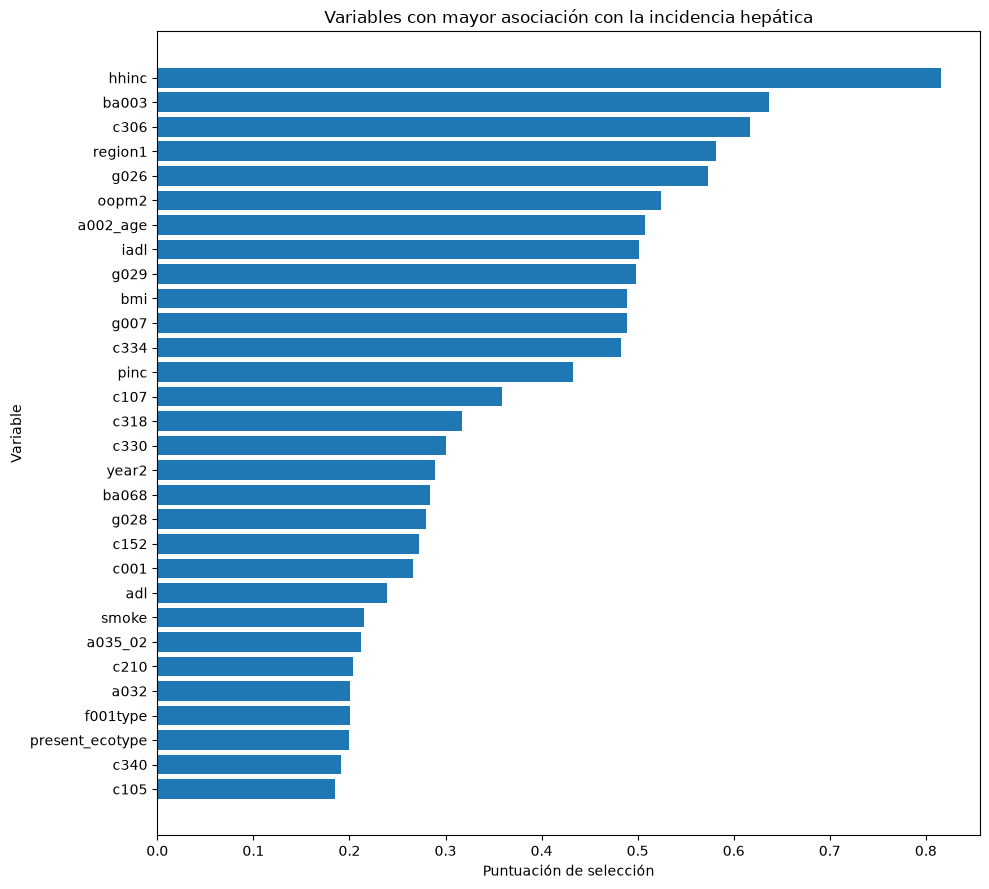

In [8]:
top_associations = (
    association_report
    .head(30)
    .sort_values(
        "selection_score"
    )
)

plt.figure(figsize=(10, 9))

plt.barh(
    top_associations["variable"],
    top_associations["selection_score"]
)

plt.xlabel("Puntuación de selección")
plt.ylabel("Variable")
plt.title(
    "Variables con mayor asociación "
    "con la incidencia hepática"
)

plt.tight_layout()

ASSOCIATION_FIGURE_PATH = (
    REPORTS_DIR
    / "target_association_ranking.png"
)

plt.savefig(
    ASSOCIATION_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [9]:
if continuous_columns:
    continuous_correlation_matrix = (
        X_train_continuous_imputed
        .corr()
    )

    absolute_correlation_matrix = (
        continuous_correlation_matrix
        .abs()
    )

    continuous_correlation_matrix.to_csv(
        REPORTS_DIR
        / "continuous_correlation_matrix.csv",
        encoding="utf-8-sig"
    )

    print(
        "Dimensiones de la matriz:",
        continuous_correlation_matrix.shape
    )

else:
    continuous_correlation_matrix = pd.DataFrame()
    absolute_correlation_matrix = pd.DataFrame()

    print(
        "No hay variables continuas "
        "para calcular correlaciones."
    )

Dimensiones de la matriz: (30, 30)


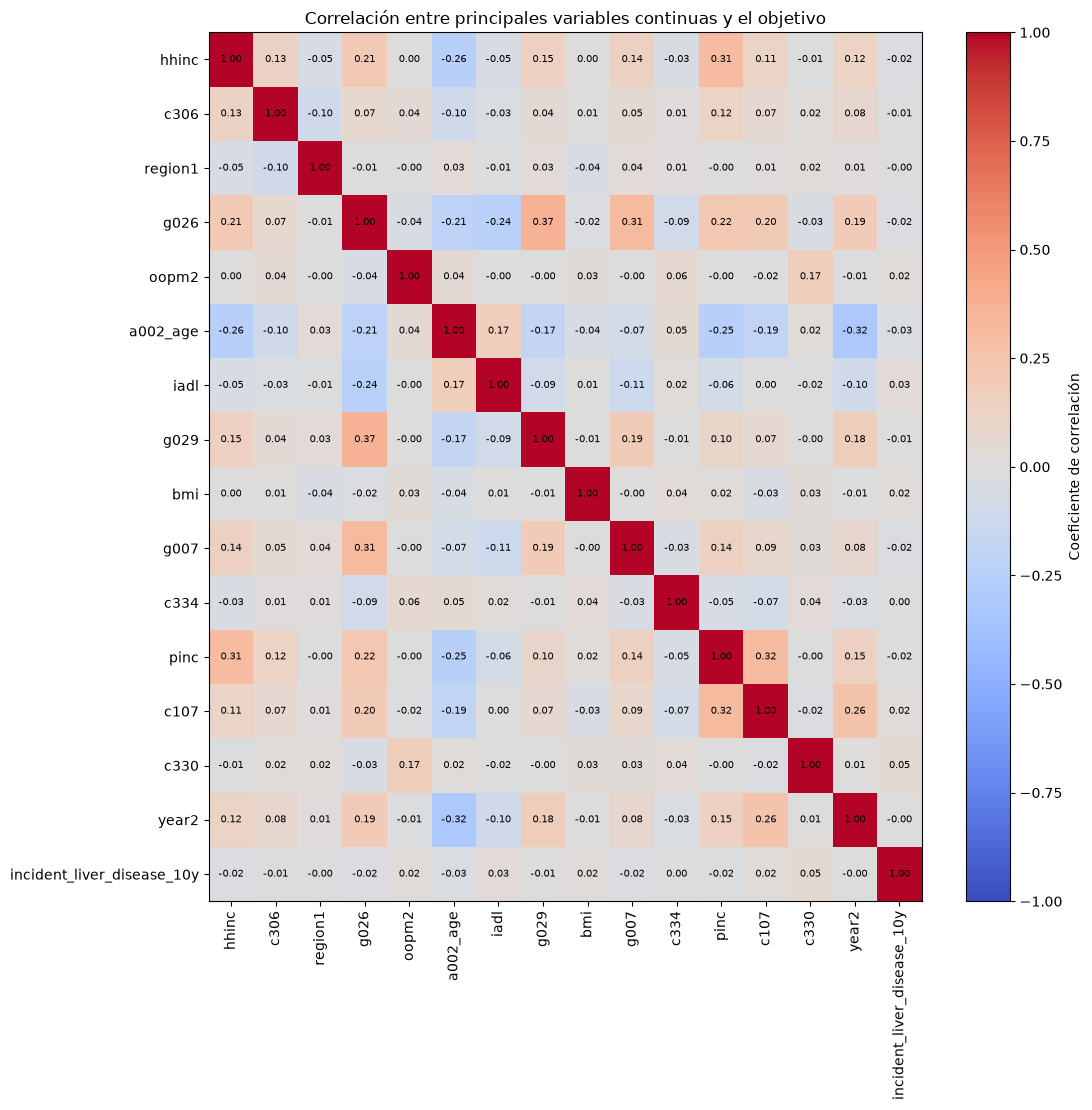

In [11]:
if continuous_columns:
    top_continuous_for_plot = (
        association_report
        .loc[
            association_report["tipo"].eq("continua")
        ]
        .head(
            min(
                CORRELATION_PLOT_TOP_N,
                len(continuous_columns)
            )
        )["variable"]
        .tolist()
    )

    correlation_plot_data = (
        X_train_continuous_imputed[
            top_continuous_for_plot
        ]
        .copy()
    )

    correlation_plot_data[TARGET] = (
        y_train.to_numpy()
    )

    visual_correlation_matrix = (
        correlation_plot_data
        .corr()
    )

    number_variables = len(
        visual_correlation_matrix.columns
    )

    figure_size = max(
        10,
        number_variables * 0.70
    )

    fig, ax = plt.subplots(
        figsize=(
            figure_size,
            figure_size
        )
    )

    image = ax.imshow(
        visual_correlation_matrix,
        vmin=-1,
        vmax=1,
        cmap="coolwarm",
        aspect="auto"
    )

    labels = (
        visual_correlation_matrix
        .columns
        .tolist()
    )

    ax.set_xticks(
        np.arange(number_variables)
    )

    ax.set_yticks(
        np.arange(number_variables)
    )

    ax.set_xticklabels(
        labels,
        rotation=90
    )

    ax.set_yticklabels(
        labels
    )

    ax.set_title(
        "Correlación entre principales variables "
        "continuas y el objetivo"
    )

    colorbar = fig.colorbar(
        image,
        ax=ax
    )

    colorbar.set_label(
        "Coeficiente de correlación"
    )

    for row in range(number_variables):
        for column in range(number_variables):
            value = (
                visual_correlation_matrix
                .iloc[row, column]
            )

            ax.text(
                column,
                row,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=7
            )

    plt.tight_layout()

    CORRELATION_FIGURE_PATH = (
        REPORTS_DIR
        / "correlation_matrix_with_target.png"
    )

    plt.savefig(
        CORRELATION_FIGURE_PATH,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [12]:
high_correlation_records = []

if not absolute_correlation_matrix.empty:
    upper_triangle = (
        absolute_correlation_matrix
        .where(
            np.triu(
                np.ones(
                    absolute_correlation_matrix.shape
                ),
                k=1
            ).astype(bool)
        )
    )

    for column in upper_triangle.columns:
        correlated_variables = (
            upper_triangle.index[
                upper_triangle[column]
                > CORRELATION_THRESHOLD
            ]
            .tolist()
        )

        for correlated_variable in correlated_variables:
            high_correlation_records.append({
                "variable_1": correlated_variable,
                "variable_2": column,
                "correlacion": (
                    continuous_correlation_matrix
                    .loc[
                        correlated_variable,
                        column
                    ]
                ),
                "correlacion_absoluta": (
                    upper_triangle
                    .loc[
                        correlated_variable,
                        column
                    ]
                )
            })

high_correlation_pairs = pd.DataFrame(
    high_correlation_records,
    columns=[
        "variable_1",
        "variable_2",
        "correlacion",
        "correlacion_absoluta"
    ]
)

if not high_correlation_pairs.empty:
    high_correlation_pairs = (
        high_correlation_pairs
        .sort_values(
            "correlacion_absoluta",
            ascending=False
        )
        .reset_index(drop=True)
    )

print(
    "Parejas con correlación absoluta superior a "
    f"{CORRELATION_THRESHOLD}: "
    f"{len(high_correlation_pairs)}"
)

display(
    high_correlation_pairs.head(40)
)

Parejas con correlación absoluta superior a 0.9: 2


,variable_1,variable_2,correlacion,correlacion_absoluta
0,a002_age,a002y,-1.0000,1.0000
1,passets,pnetassets,0.9691,0.9691


In [13]:
continuous_selection_scores = (
    association_report
    .loc[
        association_report["tipo"].eq("continua")
    ]
    .set_index("variable")[
        "selection_score"
    ]
    .to_dict()
)

ordered_continuous_columns = sorted(
    continuous_columns,
    key=lambda column: (
        continuous_selection_scores.get(
            column,
            0
        )
    ),
    reverse=True
)

retained_continuous_columns = []
redundant_records = []

for candidate in ordered_continuous_columns:
    conflicting_variable = None
    conflicting_correlation = None

    for retained in retained_continuous_columns:
        correlation = (
            absolute_correlation_matrix
            .loc[candidate, retained]
        )

        if correlation > CORRELATION_THRESHOLD:
            conflicting_variable = retained
            conflicting_correlation = correlation
            break

    if conflicting_variable is None:
        retained_continuous_columns.append(
            candidate
        )

    else:
        redundant_records.append({
            "variable_eliminada": candidate,
            "variable_conservada": conflicting_variable,
            "correlacion_absoluta": conflicting_correlation,
            "score_eliminada": (
                continuous_selection_scores
                .get(candidate, 0)
            ),
            "score_conservada": (
                continuous_selection_scores
                .get(
                    conflicting_variable,
                    0
                )
            )
        })

redundant_continuous_report = pd.DataFrame(
    redundant_records,
    columns=[
        "variable_eliminada",
        "variable_conservada",
        "correlacion_absoluta",
        "score_eliminada",
        "score_conservada"
    ]
)

print(f"Continuas iniciales: {len(continuous_columns)}")

print(
    "Continuas después de eliminar redundancia:",
    len(retained_continuous_columns)
)

print(
    "Continuas redundantes eliminadas:",
    len(redundant_continuous_report)
)

display(
    redundant_continuous_report.head(40)
)

Continuas iniciales: 30
Continuas después de eliminar redundancia: 28
Continuas redundantes eliminadas: 2


,variable_eliminada,variable_conservada,correlacion_absoluta,score_eliminada,score_conservada
0,a002y,a002_age,1.0000,0.1538,0.5075
1,pnetassets,passets,0.9691,0.0327,0.0371


In [14]:
candidate_variables = (
    retained_continuous_columns
    + categorical_columns
)

candidate_ranking = (
    association_report
    .loc[
        association_report["variable"]
        .isin(candidate_variables)
    ]
    .sort_values(
        "selection_score",
        ascending=False
    )
    .reset_index(drop=True)
)

# Variables epidemiológicas básicas conservadas
# siempre que existan en el dataset.
MANDATORY_VARIABLES = [
    column
    for column in [
        "a002_age",
        "gender1",
        "alc",
        "smoke"
    ]
    if column in candidate_variables
]

selected_variables = (
    candidate_ranking
    .head(
        min(
            TOP_K_FEATURES,
            len(candidate_ranking)
        )
    )["variable"]
    .tolist()
)

selected_variables = list(
    dict.fromkeys(
        selected_variables
        + MANDATORY_VARIABLES
    )
)

selected_continuous_columns = [
    column
    for column in selected_variables
    if column in retained_continuous_columns
]

selected_categorical_columns = [
    column
    for column in selected_variables
    if column in categorical_columns
]

selected_variables_report = (
    candidate_ranking
    .loc[
        candidate_ranking["variable"]
        .isin(selected_variables)
    ]
    .copy()
)

selected_variables_report["seleccion_manual"] = (
    selected_variables_report["variable"]
    .isin(MANDATORY_VARIABLES)
)

selected_variables_report = (
    selected_variables_report
    .sort_values(
        "selection_score",
        ascending=False
    )
    .reset_index(drop=True)
)

display(selected_variables_report)

print(
    f"Variables originales seleccionadas: "
    f"{len(selected_variables)}"
)

print(
    f"Continuas seleccionadas: "
    f"{len(selected_continuous_columns)}"
)

print(
    f"Categóricas seleccionadas: "
    f"{len(selected_categorical_columns)}"
)

,variable,tipo,mutual_information,correlacion_objetivo,correlacion_absoluta,mi_normalizada,correlacion_normalizada,selection_score,porcentaje_nulos_train,seleccion_manual
0,hhinc,continua,0.0046,-0.0197,0.0197,1.0000,0.3852,0.8156,6.5358,False
1,ba003,categórica,0.0029,NaN,NaN,0.6369,0.0000,0.6369,0.0000,False
2,c306,continua,0.0037,-0.0101,0.0101,0.7965,0.1964,0.6165,36.3758,False
3,region1,continua,0.0037,-0.0039,0.0039,0.7980,0.0764,0.5815,0.0000,False
4,g026,continua,0.0029,-0.0217,0.0217,0.6367,0.4241,0.5729,0.0000,False
5,oopm2,continua,0.0026,0.0230,0.0230,0.5576,0.4484,0.5248,22.7325,False
6,a002_age,continua,0.0023,-0.0263,0.0263,0.5053,0.5126,0.5075,0.0000,True
7,iadl,continua,0.0021,0.0327,0.0327,0.4433,0.6378,0.5016,0.0000,False
8,g029,continua,0.0030,-0.0068,0.0068,0.6557,0.1321,0.4986,2.1723,False
9,bmi,continua,0.0023,0.0229,0.0229,0.5065,0.4480,0.4889,1.8293,False


Variables originales seleccionadas: 32
Continuas seleccionadas: 19
Categóricas seleccionadas: 13


In [15]:
main_transformers = []

if selected_continuous_columns:
    continuous_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="median",
                    add_indicator=True
                )
            ),
            (
                "scaler",
                StandardScaler()
            )
        ]
    )

    main_transformers.append(
        (
            "continuous",
            continuous_pipeline,
            selected_continuous_columns
        )
    )

if selected_categorical_columns:
    categorical_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="most_frequent"
                )
            ),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore",
                    min_frequency=MIN_CATEGORY_FREQUENCY,
                    sparse_output=True
                )
            )
        ]
    )

    main_transformers.append(
        (
            "categorical",
            categorical_pipeline,
            selected_categorical_columns
        )
    )

if not main_transformers:
    raise ValueError(
        "No existen variables seleccionadas "
        "para construir el preprocessor."
    )

final_preprocessor = ColumnTransformer(
    transformers=main_transformers,
    remainder="drop"
)

print("Preprocessor principal creado.")

Preprocessor principal creado.


In [16]:
X_train_selected = X_train[
    selected_variables
].copy()

X_test_selected = X_test[
    selected_variables
].copy()

preprocessor_preview = clone(
    final_preprocessor
)

X_train_preview = (
    preprocessor_preview
    .fit_transform(
        X_train_selected
    )
)

X_test_preview = (
    preprocessor_preview
    .transform(
        X_test_selected
    )
)

transformed_feature_names = (
    preprocessor_preview
    .get_feature_names_out()
)

transformed_features_report = pd.DataFrame({
    "variable_transformada": transformed_feature_names
})

print(
    "Variables originales seleccionadas:",
    len(selected_variables)
)

print(
    "Características tras imputación y One-Hot:",
    X_train_preview.shape[1]
)

print(
    "Train transformado:",
    X_train_preview.shape
)

print(
    "Test transformado:",
    X_test_preview.shape
)

display(
    transformed_features_report.head(50)
)

Variables originales seleccionadas: 32
Características tras imputación y One-Hot: 106
Train transformado: (5248, 106)
Test transformado: (1312, 106)


,variable_transformada
0,continuous__hhinc
1,continuous__c306
2,continuous__region1
3,continuous__g026
4,continuous__oopm2
5,continuous__a002_age
6,continuous__iadl
7,continuous__g029
8,continuous__bmi
9,continuous__g007


In [17]:
if selected_continuous_columns:
    pca_input_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="median"
                )
            ),
            (
                "scaler",
                StandardScaler()
            )
        ]
    )

    X_train_continuous_scaled = (
        pca_input_pipeline
        .fit_transform(
            X_train[
                selected_continuous_columns
            ]
        )
    )

    pca_full = PCA()

    X_train_pca_full = (
        pca_full.fit_transform(
            X_train_continuous_scaled
        )
    )

    explained_variance = (
        pca_full.explained_variance_ratio_
    )

    cumulative_variance = np.cumsum(
        explained_variance
    )

    def components_for_variance(
        cumulative_values: np.ndarray,
        threshold: float
    ) -> int:
        return int(
            np.searchsorted(
                cumulative_values,
                threshold
            )
            + 1
        )

    n_components_90 = components_for_variance(
        cumulative_variance,
        0.90
    )

    n_components_95 = components_for_variance(
        cumulative_variance,
        0.95
    )

    n_components_99 = components_for_variance(
        cumulative_variance,
        0.99
    )

    pca_variance_report = pd.DataFrame({
        "componente": np.arange(
            1,
            len(explained_variance) + 1
        ),
        "varianza_explicada": explained_variance,
        "varianza_acumulada": cumulative_variance
    })

    print(
        f"Continuas seleccionadas: "
        f"{len(selected_continuous_columns)}"
    )

    print(
        f"Componentes para explicar 90%: "
        f"{n_components_90}"
    )

    print(
        f"Componentes para explicar 95%: "
        f"{n_components_95}"
    )

    print(
        f"Componentes para explicar 99%: "
        f"{n_components_99}"
    )

    display(
        pca_variance_report.head(20)
    )

else:
    pca_input_pipeline = None
    pca_full = None
    pca_variance_report = pd.DataFrame()

    n_components_90 = 0
    n_components_95 = 0
    n_components_99 = 0

    print(
        "No existen continuas seleccionadas "
        "para aplicar PCA."
    )

Continuas seleccionadas: 19
Componentes para explicar 90%: 15
Componentes para explicar 95%: 16
Componentes para explicar 99%: 18


,componente,varianza_explicada,varianza_acumulada
0,1,0.1632,0.1632
1,2,0.0965,0.2597
2,3,0.0817,0.3414
3,4,0.0643,0.4056
4,5,0.0597,0.4653
5,6,0.0584,0.5236
6,7,0.0543,0.5780
7,8,0.0519,0.6298
8,9,0.0500,0.6799
9,10,0.0489,0.7288


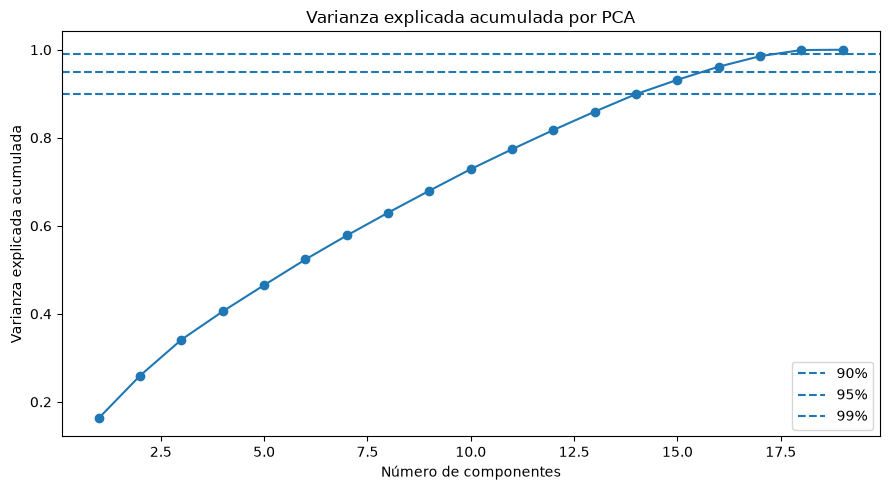

In [18]:
if not pca_variance_report.empty:
    plt.figure(figsize=(9, 5))

    plt.plot(
        pca_variance_report["componente"],
        pca_variance_report["varianza_acumulada"],
        marker="o"
    )

    plt.axhline(
        0.90,
        linestyle="--",
        label="90%"
    )

    plt.axhline(
        0.95,
        linestyle="--",
        label="95%"
    )

    plt.axhline(
        0.99,
        linestyle="--",
        label="99%"
    )

    plt.xlabel("Número de componentes")
    plt.ylabel("Varianza explicada acumulada")
    plt.title(
        "Varianza explicada acumulada por PCA"
    )

    plt.legend()
    plt.tight_layout()

    PCA_FIGURE_PATH = (
        REPORTS_DIR
        / "pca_explained_variance.png"
    )

    plt.savefig(
        PCA_FIGURE_PATH,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [19]:
if pca_full is not None:
    component_names = [
        f"PC{index}"
        for index in range(
            1,
            len(
                pca_full.explained_variance_ratio_
            )
            + 1
        )
    ]

    pca_loadings = pd.DataFrame(
        pca_full.components_.T,
        index=selected_continuous_columns,
        columns=component_names
    )

    top_pca_loadings = []

    components_to_show = min(
        5,
        len(component_names)
    )

    for component in component_names[
        :components_to_show
    ]:
        top_variables = (
            pca_loadings[component]
            .abs()
            .sort_values(
                ascending=False
            )
            .head(10)
        )

        for variable, absolute_loading in (
            top_variables.items()
        ):
            top_pca_loadings.append({
                "componente": component,
                "variable": variable,
                "carga": (
                    pca_loadings.loc[
                        variable,
                        component
                    ]
                ),
                "carga_absoluta": absolute_loading
            })

    top_pca_loadings_report = pd.DataFrame(
        top_pca_loadings
    )

    display(
        top_pca_loadings_report
    )

else:
    pca_loadings = pd.DataFrame()
    top_pca_loadings_report = pd.DataFrame()

,componente,variable,carga,carga_absoluta
0,PC1,a002_age,0.3672,0.3672
1,PC1,ba068,0.3425,0.3425
2,PC1,g026,-0.3320,0.3320
3,PC1,c107,-0.3176,0.3176
4,PC1,pinc,-0.3043,0.3043
5,PC1,c105,-0.2940,0.2940
6,PC1,year2,-0.2694,0.2694
7,PC1,g029,-0.2624,0.2624
8,PC1,hhinc,-0.2624,0.2624
9,PC1,g028,-0.2347,0.2347


In [20]:
pca_transformers = []

if selected_continuous_columns:
    pca_continuous_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="median"
                )
            ),
            (
                "scaler",
                StandardScaler()
            ),
            (
                "pca",
                PCA(
                    n_components=PCA_VARIANCE_THRESHOLD,
                    svd_solver="full"
                )
            )
        ]
    )

    pca_transformers.append(
        (
            "continuous_pca",
            pca_continuous_pipeline,
            selected_continuous_columns
        )
    )

if selected_categorical_columns:
    pca_categorical_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="most_frequent"
                )
            ),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore",
                    min_frequency=MIN_CATEGORY_FREQUENCY,
                    sparse_output=True
                )
            )
        ]
    )

    pca_transformers.append(
        (
            "categorical",
            pca_categorical_pipeline,
            selected_categorical_columns
        )
    )

pca_preprocessor = ColumnTransformer(
    transformers=pca_transformers,
    remainder="drop"
)

print("Preprocessor alternativo con PCA creado.")

Preprocessor alternativo con PCA creado.


In [21]:
SELECTED_DATASET_PATH = (
    PROCESSED_DIR
    / "klosa_liver_selected_features_dataset.csv"
)

SPLIT_REPORT_PATH = (
    REPORTS_DIR
    / "train_test_split.csv"
)

FINAL_PREPROCESSOR_PATH = (
    MODELS_DIR
    / "selected_features_preprocessor_template.joblib"
)

PCA_PREPROCESSOR_PATH = (
    MODELS_DIR
    / "pca_preprocessor_template.joblib"
)

SELECTED_CONFIG_PATH = (
    CONFIGS_DIR
    / "selected_variables.json"
)

selected_dataset_columns = [
    ID_COLUMN,
    *selected_variables,
    TARGET
]

if WEIGHT_COLUMN in df.columns:
    selected_dataset_columns.insert(
        1,
        WEIGHT_COLUMN
    )

selected_dataset = df[
    selected_dataset_columns
].copy()

selected_dataset.to_csv(
    SELECTED_DATASET_PATH,
    index=False,
    encoding="utf-8-sig"
)

split_report.to_csv(
    SPLIT_REPORT_PATH,
    index=False,
    encoding="utf-8-sig"
)

association_report.to_csv(
    REPORTS_DIR / "target_associations.csv",
    index=False,
    encoding="utf-8-sig"
)

high_correlation_pairs.to_csv(
    REPORTS_DIR / "high_correlation_pairs.csv",
    index=False,
    encoding="utf-8-sig"
)

redundant_continuous_report.to_csv(
    REPORTS_DIR
    / "redundant_continuous_variables.csv",
    index=False,
    encoding="utf-8-sig"
)

selected_variables_report.to_csv(
    REPORTS_DIR / "selected_variables.csv",
    index=False,
    encoding="utf-8-sig"
)

transformed_features_report.to_csv(
    REPORTS_DIR
    / "onehot_feature_names_preview.csv",
    index=False,
    encoding="utf-8-sig"
)

if not pca_variance_report.empty:
    pca_variance_report.to_csv(
        REPORTS_DIR / "pca_explained_variance.csv",
        index=False,
        encoding="utf-8-sig"
    )

if not pca_loadings.empty:
    pca_loadings.to_csv(
        REPORTS_DIR / "pca_loadings.csv",
        encoding="utf-8-sig"
    )

if not top_pca_loadings_report.empty:
    top_pca_loadings_report.to_csv(
        REPORTS_DIR / "top_pca_loadings.csv",
        index=False,
        encoding="utf-8-sig"
    )

selected_configuration = {
    "target": TARGET,
    "id_column": ID_COLUMN,
    "weight_column": WEIGHT_COLUMN,
    "random_state": RANDOM_STATE,
    "test_size": TEST_SIZE,
    "correlation_threshold": CORRELATION_THRESHOLD,
    "top_k_features": TOP_K_FEATURES,
    "pca_variance_threshold": PCA_VARIANCE_THRESHOLD,
    "min_category_frequency": MIN_CATEGORY_FREQUENCY,
    "selected_variables": selected_variables,
    "selected_continuous_columns": (
        selected_continuous_columns
    ),
    "selected_categorical_columns": (
        selected_categorical_columns
    ),
    "mandatory_variables": MANDATORY_VARIABLES,
    "pca_components_90": n_components_90,
    "pca_components_95": n_components_95,
    "pca_components_99": n_components_99
}

with open(
    SELECTED_CONFIG_PATH,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        selected_configuration,
        file,
        indent=4,
        ensure_ascii=False
    )

# Se guardan sin ajustar para usarlos dentro
# de cada fold de validación cruzada.
joblib.dump(
    final_preprocessor,
    FINAL_PREPROCESSOR_PATH
)

joblib.dump(
    pca_preprocessor,
    PCA_PREPROCESSOR_PATH
)

print("RESULTADOS GUARDADOS")
print("=" * 60)
print(f"Dataset seleccionado: {SELECTED_DATASET_PATH}")
print(f"División train/test: {SPLIT_REPORT_PATH}")
print(f"Configuración: {SELECTED_CONFIG_PATH}")
print(f"Preprocessor principal: {FINAL_PREPROCESSOR_PATH}")
print(f"Preprocessor PCA: {PCA_PREPROCESSOR_PATH}")

RESULTADOS GUARDADOS
Dataset seleccionado: C:\Users\DAVID\TFM_Liver_Disease_Risk\data\processed\klosa_liver_selected_features_dataset.csv
División train/test: C:\Users\DAVID\TFM_Liver_Disease_Risk\reports\feature_selection\train_test_split.csv
Configuración: C:\Users\DAVID\TFM_Liver_Disease_Risk\configs\selected_variables.json
Preprocessor principal: C:\Users\DAVID\TFM_Liver_Disease_Risk\models\selected_features_preprocessor_template.joblib
Preprocessor PCA: C:\Users\DAVID\TFM_Liver_Disease_Risk\models\pca_preprocessor_template.joblib


In [22]:
expected_files = [
    SELECTED_DATASET_PATH,
    SPLIT_REPORT_PATH,
    SELECTED_CONFIG_PATH,
    FINAL_PREPROCESSOR_PATH,
    PCA_PREPROCESSOR_PATH,
    REPORTS_DIR / "target_associations.csv",
    REPORTS_DIR / "continuous_correlation_matrix.csv",
    REPORTS_DIR / "selected_variables.csv",
    REPORTS_DIR / "correlation_matrix_with_target.png"
]

for path in expected_files:
    print(
        f"{path.name}:",
        "OK" if path.exists() else "NO CREADO"
    )

klosa_liver_selected_features_dataset.csv: OK
train_test_split.csv: OK
selected_variables.json: OK
selected_features_preprocessor_template.joblib: OK
pca_preprocessor_template.joblib: OK
target_associations.csv: OK
continuous_correlation_matrix.csv: OK
selected_variables.csv: OK
correlation_matrix_with_target.png: OK


In [23]:
print("RESUMEN DEL NOTEBOOK 05")
print("=" * 60)

print(
    f"Predictores iniciales: "
    f"{len(feature_columns)}"
)

print(
    f"Continuas iniciales: "
    f"{len(continuous_columns)}"
)

print(
    f"Categóricas iniciales: "
    f"{len(categorical_columns)}"
)

print(
    f"Continuas redundantes eliminadas: "
    f"{len(redundant_continuous_report)}"
)

print(
    f"Variables originales seleccionadas: "
    f"{len(selected_variables)}"
)

print(
    f"Continuas seleccionadas: "
    f"{len(selected_continuous_columns)}"
)

print(
    f"Categóricas seleccionadas: "
    f"{len(selected_categorical_columns)}"
)

print(
    f"Características después del One-Hot: "
    f"{X_train_preview.shape[1]}"
)

if not pca_variance_report.empty:
    print(
        f"Componentes PCA para explicar el 95%: "
        f"{n_components_95}"
    )

print("\nNotebook 05 completado.")

print(
    "\nEstrategia principal para el notebook 06:"
    "\n- Variables originales seleccionadas."
    "\n- Imputación por mediana para continuas."
    "\n- StandardScaler para continuas."
    "\n- Imputación por moda para categóricas."
    "\n- One-Hot Encoding para categóricas."
    "\n- Balanceo aplicado solo dentro de entrenamiento."
)

RESUMEN DEL NOTEBOOK 05
Predictores iniciales: 125
Continuas iniciales: 30
Categóricas iniciales: 95
Continuas redundantes eliminadas: 2
Variables originales seleccionadas: 32
Continuas seleccionadas: 19
Categóricas seleccionadas: 13
Características después del One-Hot: 106
Componentes PCA para explicar el 95%: 16

Notebook 05 completado.

Estrategia principal para el notebook 06:
- Variables originales seleccionadas.
- Imputación por mediana para continuas.
- StandardScaler para continuas.
- Imputación por moda para categóricas.
- One-Hot Encoding para categóricas.
- Balanceo aplicado solo dentro de entrenamiento.
